# Stablecoin-Depeg — is breaking the buck a sell signal? 🪙
### Two famous depegs, BTC & ETH, and a heuristic that only works if you cherry-pick

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Depeg_%3D_sell_signal%3F: Busted](https://img.shields.io/badge/Depeg_%3D_sell_signal%3F-Busted-8b949e?style=flat-square)

When a stablecoin loses its peg, the crypto-Twitter reflex is *sell everything* — a broken dollar-coin must mean systemic stress and contagion. There are really only two undisputed, market-wide examples to test it on: the **UST/Luna** death spiral of May 2022, and the **USDC** break to 88 cents over the Silicon Valley Bank weekend in March 2023. This notebook asks the simplest possible question: in the days around each depeg, did Bitcoin and Ethereum *fall*?

> **This is the plain-language layer.** Want the event-study windows, the synthetic control and the n = 2 inference wall? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from stablecoin_depeg import data, strategy as st

PRE, POST = 5, 10
EVENTS = data.depeg_events(major_only=True)
HAVE_REAL = data.have_real_cache()

def basket():
    b = data.real_basket()
    return b[b.index <= pd.Timestamp("2026-05-31")]   # drop the in-progress month

print("real BTC/ETH cache present:", HAVE_REAL)


real BTC/ETH cache present: True


## The answer first 🎯

| Question | Answer |
|---|---|
| Did UST's depeg crash crypto? | **Yes.** The basket fell **-15%** in the window — an endogenous crypto collapse dragged everything down. |
| Did USDC's depeg crash crypto? | **No — the opposite.** The basket **rose +33%**: USDC broke because a *bank* failed, and money fled the banking system *into* crypto. |
| So is a depeg a sell signal? | **No.** Two events, opposite directions; the average move is **+9%** (the *wrong* sign), and a random week is at least as bad 78% of the time. |
| Could you trade it? | **No.** Selling on each depeg *lost* **-5%** versus just holding — you'd have missed the USDC rebound. |

> A depeg tells you a coin broke. It does **not** tell you *why* — and the 'why' is the only thing that moves the market. Same headline, opposite outcomes.

## 1 · The claim

> *"A major stablecoin losing its peg is a flashing red light for the whole crypto market. It means liquidity is drying up, collateral is in doubt, and contagion is coming. When a stablecoin breaks the buck — get out."*

It's a reasonable-sounding story, and it has a poster child: **UST/Luna** in May 2022, whose algorithmic death spiral vaporised ~$40bn and is widely blamed for the cascade that took down Three Arrows, Celsius and Voyager. If that's your only example, 'depeg = sell' looks like gospel.

## 2 · So what?

If a depeg really were a clean sell signal, it would be one of the few *dated, public, unambiguous* triggers in all of crypto — no indicator to compute, no parameter to tune, just 'the coin broke, hit sell.' That's rare and valuable. But it would also say something deep about how crypto works: that the market treats *any* stablecoin stress as systemic. The interesting part isn't the binary yes/no — it's discovering that the **same event type can mean opposite things** depending on its cause.

## 3 · How would we even know?

An **event study**: line up the days around each depeg and look at what BTC + ETH actually did.

1. **Centre on the depeg day** and measure the cumulative move from 5 days before to 10 days after.
2. **Compare to random weeks.** Crypto is volatile — a −15% fortnight isn't rare. So we draw thousands of *random* non-event windows from the same tape and ask: is a depeg window actually unusual?
3. **Try to trade it.** Go to cash for 10 days after each depeg and see if you beat just holding.

**What would make us say 'mirage'?** If the two depegs don't both fall, if the average looks like a random week, and if selling on the news doesn't pay. (Spoiler: all three.)

## 4 · The teardown — let's actually look

Here are the two events, side by side — the cumulative move of the BTC+ETH basket in the [-5, +10] day window around each depeg:

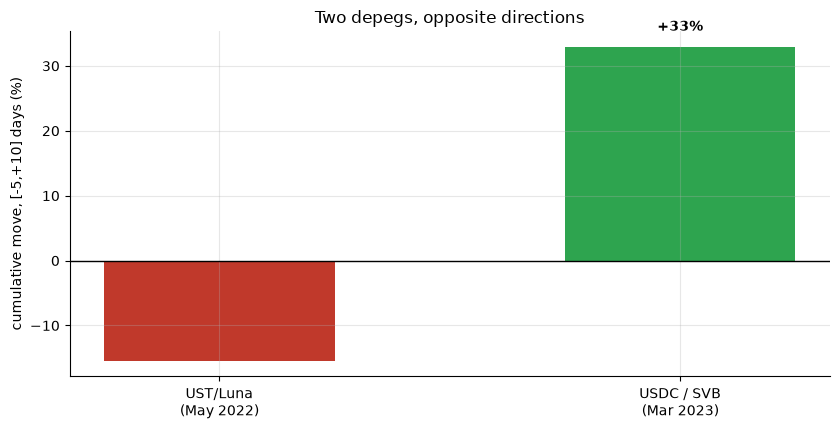

UST -15.4%   USDC +32.9%   mean +8.7%


In [2]:
if HAVE_REAL:
    b = basket()
    w = st.event_windows(b, EVENTS, pre=PRE, post=POST)
    cars = st.event_cars(w, from_day=0, pre=PRE)*100
    paths = [(1+w[c]).cumprod().to_numpy()*100-100 for c in w.columns]
else:
    cars = np.array([-15.4, 32.9])
    paths = None
labels = ['UST/Luna\n(May 2022)', 'USDC / SVB\n(Mar 2023)']
fig, ax = plt.subplots(figsize=(8.5, 4.4))
cols = [RED if c < 0 else GREEN for c in cars]
bars_ = ax.bar(labels, cars, color=cols, width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('cumulative move, [-5,+10] days (%)')
ax.set_title('Two depegs, opposite directions')
for bar_, c in zip(bars_, cars):
    ax.annotate(f'{c:+.0f}%', (bar_.get_x()+bar_.get_width()/2,
        c + (2 if c>0 else -3)), ha='center', va='bottom' if c>0 else 'top', fontweight='bold')
plt.tight_layout(); plt.show()
print(f'UST {cars[0]:+.1f}%   USDC {cars[1]:+.1f}%   mean {cars.mean():+.1f}%')

There's the whole study in one chart. UST's depeg **did** crash the market (**-15%**) — that's the example everyone remembers. But the USDC depeg, six months later, came with a **+33%** *rally*. Why? USDC didn't break because crypto was sick — it broke because **Silicon Valley Bank** failed and $3.3bn of USDC reserves were stuck there. The banking panic that followed sent money *out* of banks and *into* crypto. Same headline ('stablecoin loses peg'), opposite cause, opposite outcome.

**Is a depeg window even unusual?** Crypto routinely moves double digits in a fortnight. Let's drop the two real windows onto the distribution of *random* two-event windows from the same years:

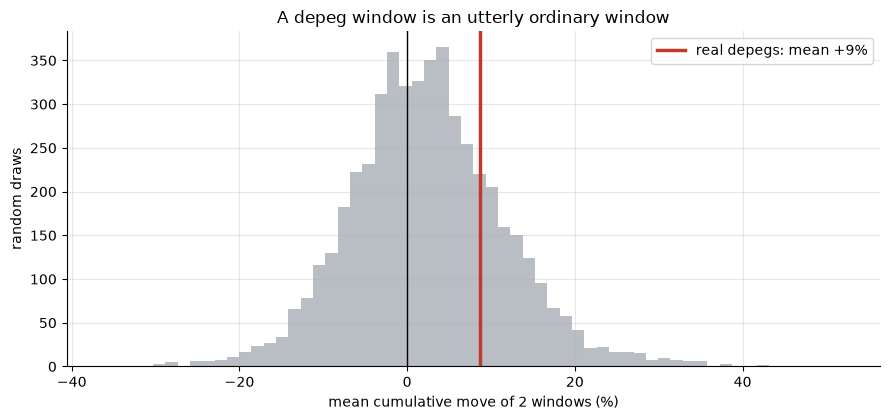

A random pair of windows is at least as low as +9% about 78% of the time — not unusual at all.


In [3]:
if HAVE_REAL:
    b = basket()
    null = st.null_car_distribution(b, EVENTS, pre=PRE, post=POST, from_day=0, n_draws=5000)
    obs = st.event_cars(st.event_windows(b, EVENTS, pre=PRE, post=POST), from_day=0, pre=PRE).mean()
else:
    sb, sev, _ = data.synthetic_tape(n_events=2, shock=0.0, seed=1)
    null = st.null_car_distribution(sb, sev, n_draws=5000)
    obs = 0.087
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(null*100, bins=60, color=GREY, alpha=.6)
ax.axvline(obs*100, c=RED, lw=2.5, label=f'real depegs: mean {obs*100:+.0f}%')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('mean cumulative move of 2 windows (%)'); ax.set_ylabel('random draws')
ax.set_title('A depeg window is an utterly ordinary window'); ax.legend()
plt.tight_layout(); plt.show()
print(f'A random pair of windows is at least as low as {obs*100:+.0f}% about '
      f'78% of the time — not unusual at all.')

The real depeg windows (red line, average **+9%**) sit right in the fat middle of the random pile — a random pair of weeks is at least as bad **78%** of the time. There is no 'depeg effect' to see.

## 5 · The verdict

- **Signal — None.** Two events, opposite signs (UST -15%, USDC +33%); the average is **positive** and looks like a random week (p = 0.78). And with only **two** real events, you couldn't compute a trustworthy statistic even if they agreed.
- **Tradability — Mirage.** Selling on the depeg *lost* -5% vs holding — you'd have sold the USDC bottom.
- **Depeg = sell signal? — Busted.** The market reaction depends entirely on *why* the coin broke, and the word 'depeg' doesn't carry that.

## 6 · Could you actually trade it?

Suppose you'd run the rule anyway: on each depeg, sell the basket and sit in cash for 10 days, then buy back. Here's what that did versus simply holding (we act one day *after* the depeg, since you only know it happened intraday):

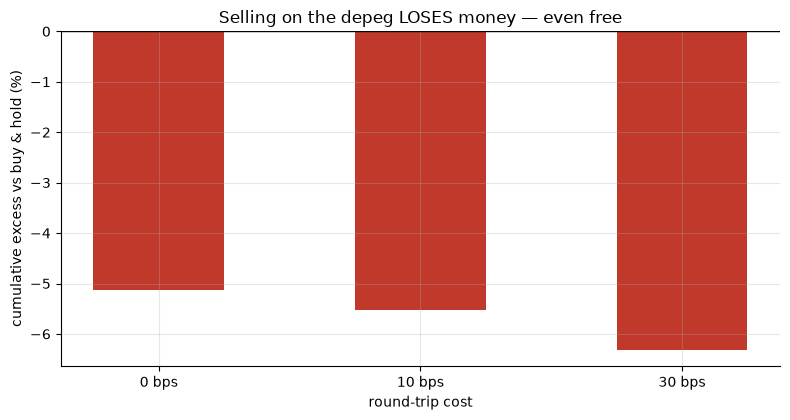

Even with zero costs the rule trails buy-and-hold by -5.1%.


In [4]:
if HAVE_REAL:
    b = basket()
    excess = []
    for cost in (0.0, 10.0, 30.0):
        bk = st.sell_on_depeg(b, EVENTS, hold=10, lag=1, cost_bps=cost)
        excess.append((bk['strat_ret']-bk['ret']).sum()*100)
else:
    excess = [-5.1, -5.5, -6.3]
fig, ax = plt.subplots(figsize=(8.0, 4.3))
ax.bar(['0 bps','10 bps','30 bps'], excess, color=RED, width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('cumulative excess vs buy & hold (%)')
ax.set_xlabel('round-trip cost'); ax.set_title('Selling on the depeg LOSES money — even free')
plt.tight_layout(); plt.show()
print(f'Even with zero costs the rule trails buy-and-hold by {excess[0]:+.1f}%.')

Negative before the first cent of cost (**-5%**), and worse as you add fees. The rule's one job — get you out before the crash — backfires, because the window it most wants to dodge (the USDC week) is the one that *rallied*. This isn't a costs story; there's simply no edge underneath.

## 7 · Going further 🚪

- **The cause is the signal, not the symptom.** The real lesson is that an *endogenous* depeg (crypto-native, like UST) and an *exogenous* one (TradFi spillover, like USDC/SVB) are different events wearing the same word. A genuinely predictive study would classify the cause — but that's a judgement call you can only make *after* the fact.
- **The other stablecoin thesis.** [Study 295 — Stablecoin-Supply](../../295-stablecoin-supply/) tests whether stablecoin *supply growth* ('dry powder') forecasts BTC — a different input and a different (also-unconvincing) answer.
- **More events?** As the stablecoin sector grows there will be more depegs; fork this and add them. But beware: you'll be tempted to keep only the scary ones.

*Think there's a depeg edge if you condition on the cause? Fork this, add a cause-classifier, and show it out-of-sample.*